In [1]:
import os
import torch
import json 
import re
import ast
import hashlib

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from collections import defaultdict
from torch_geometric.data import Data, HeteroData, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.nn import to_hetero
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
from collections import Counter

C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Load sub-graph data

In [2]:
isco = False

if isco:
    df_graphs = pd.read_parquet("../kg_construction/subgraphs_isco_no_inference_strict.parquet")
else:
    df_graphs = pd.read_parquet("../kg_construction/subgraphs_no_inference_strict.parquet")
 
df_graphs.head()

,isco,model,prompt,vacancy,cvid,response,graph,num_nodes,num_edges,density,avg_degree,avg_clustering,path_exists,shortest_path_length
0,False,qwen,structured,1527549.0,1ea333bcf408489d88d6bb4ecad3852d,0,"{""directed"": false, ""multigraph"": false, ""grap...",66,71,0.032564,2.149254,0.0,True,3
1,False,qwen,structured,1527507.0,6f38a6778f1249b5b14658aed49f5348,0,"{""directed"": false, ""multigraph"": false, ""grap...",41,39,0.046458,1.904762,0.0,True,4
2,False,qwen,structured,1527507.0,238e44044b5348e09dba220756613ac6,0,"{""directed"": false, ""multigraph"": false, ""grap...",62,72,0.037378,2.317460,0.0,True,4
3,False,qwen,structured,1527507.0,6e5a9a5cac7e454bb17c85853850b108,0,"{""directed"": false, ""multigraph"": false, ""grap...",52,60,0.044267,2.301887,0.0,True,4
4,False,qwen,structured,1527507.0,2772752bd7fb4fdebd3c2cdbf7539ee7,1,"{""directed"": false, ""multigraph"": false, ""grap...",43,46,0.049683,2.136364,0.0,True,4


C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\drawing\nx_pylab.py:1375: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(self.x, self.y, *args, rotation=self.angle, **kwargs)


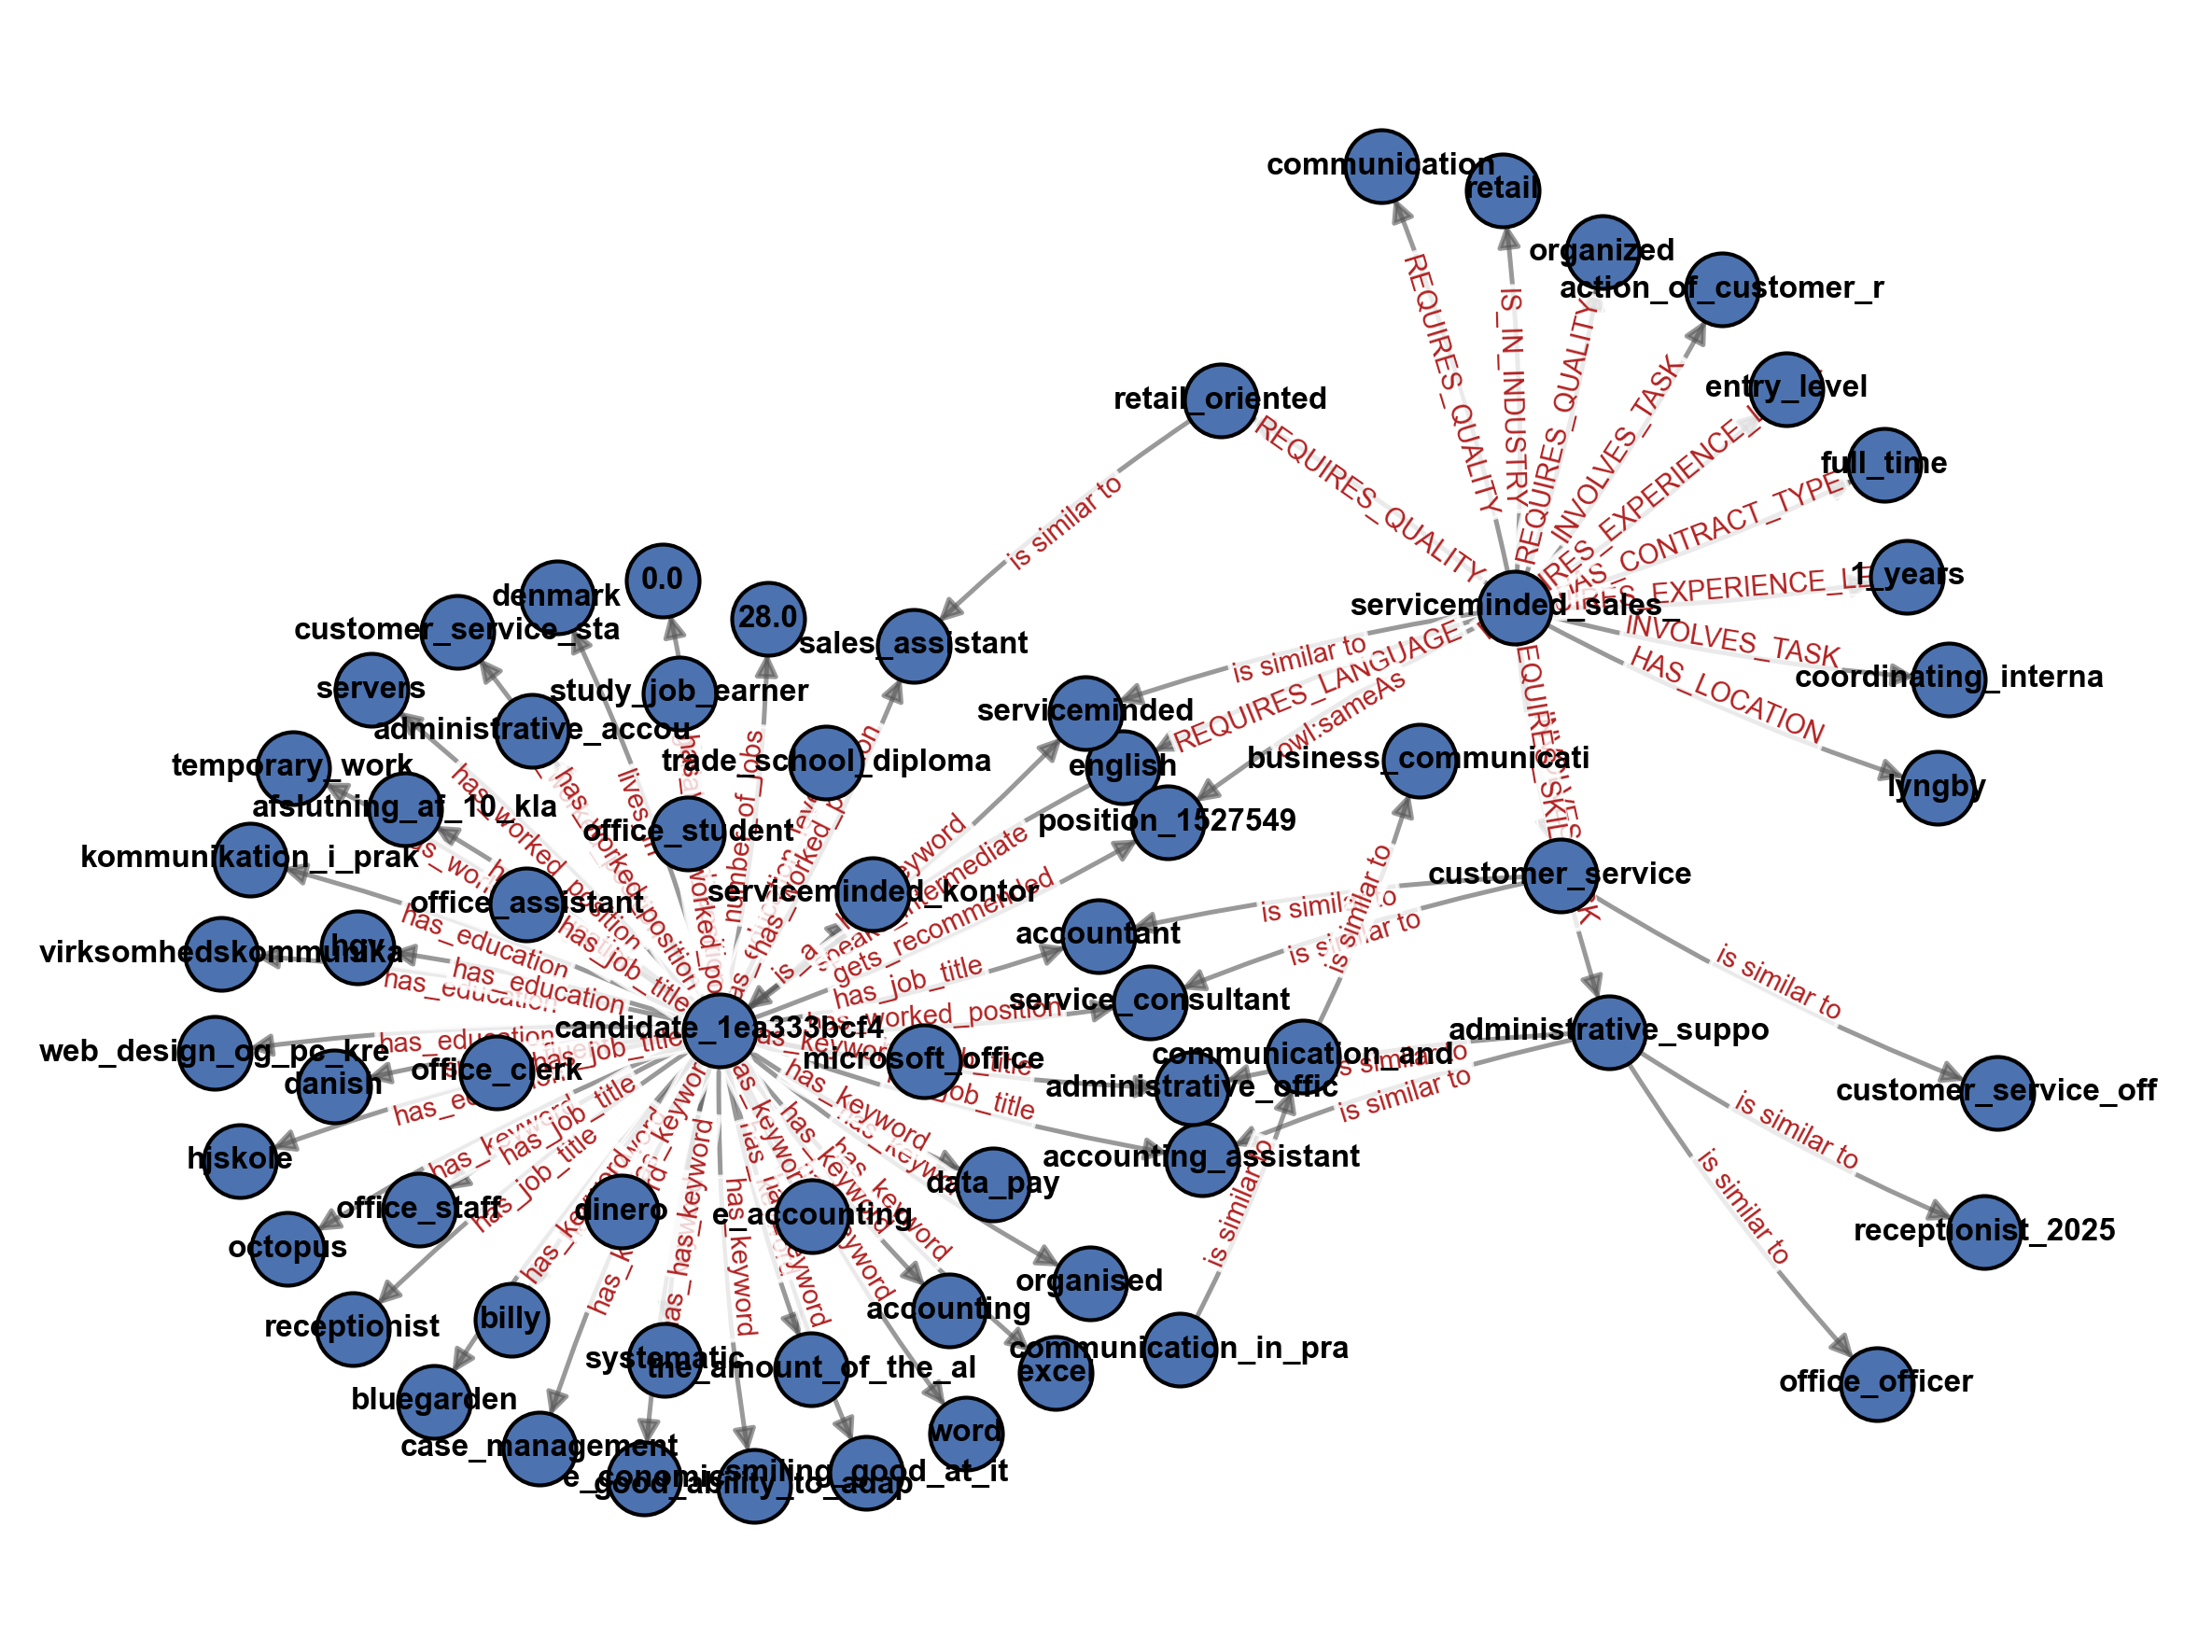

In [3]:
def plot_clean_graph(G, output_filename="sub_graph_no_inference.pdf"):
    # 0. SET PUBLICATION PARAMETERS
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'figure.dpi': 300 
    })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. REMOVE SELF-LOOPS
    display_G = G.copy()
    display_G.remove_edges_from(nx.selfloop_edges(display_G))
    
    # 2. POSITIONAL LAYOUT
    pos = nx.kamada_kawai_layout(display_G)
    
    # 3. DRAW NODES
    nx.draw_networkx_nodes(
        display_G, pos,
        ax=ax,
        node_size=350,
        node_color='#4C72B0',
        edgecolors='black',
        linewidths=1.0
    )
    
    # 4. DRAW EDGES
    nx.draw_networkx_edges(
        display_G, pos,
        ax=ax,
        alpha=0.6,
        edge_color='#555555',
        arrows=True,
        arrowsize=12,
        arrowstyle='-|>',
        width=1.2,
        connectionstyle='arc3,rad=0.05' 
    )
    
    # 4.5 DRAW EDGE LABELS
    # IMPORTANT: Change 'label' to whatever key your edge data uses (e.g., 'weight', 'relation')
    edge_labels = nx.get_edge_attributes(display_G, 'edge_type')
    
    nx.draw_networkx_edge_labels(
        display_G, pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=7,
        font_color='#B22222', # Dark red to stand out from nodes/edges
        bbox=dict(alpha=0.8, color='white', edgecolor='none', pad=0.5) # White background so lines don't obscure text
    )
    
    # 5. CLEAN LABELS
    labels = {n: str(n).replace("jie:", "").replace("_jie_", "").split('/')[-1][:20] 
              for n in display_G.nodes()}
    
    nx.draw_networkx_labels(
        display_G, pos, labels,
        ax=ax,
        font_size=8,
        font_weight='bold',
        font_color='black'
    )
    
    # 6. FINALIZE & EXPORT
    ax.axis('off')
    plt.tight_layout() 
    
    plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

data_dict = json.loads(df_graphs.iloc[0]["graph"])
g = nx.node_link_graph(data_dict)

plot_clean_graph(g)

In [4]:
# 1. Create a combined tuple column
df_graphs['cvid_vacancy'] = list(zip(df_graphs['cvid'], df_graphs['vacancy']))

# 2. Group by model and prompt, then find unique counts
result = df_graphs.groupby(['model', 'prompt'])['cvid_vacancy'].nunique().reset_index()
result

,model,prompt,cvid_vacancy
0,gemma,semi-structured,19117
1,gemma,structured,19117
2,gemma,unstructured,19117
3,llama,semi-structured,19117
4,llama,structured,19117
5,llama,unstructured,19117
6,qwen,semi-structured,19117
7,qwen,structured,19117
8,qwen,unstructured,19117


In [5]:
df_graphs["response"].value_counts()

response
0    157833
1     14328
Name: count, dtype: int64

In [6]:
non_zero = df_graphs.groupby("cvid")["response"].sum() > 0
non_zero = set(non_zero[non_zero == True].index)
len(non_zero), len(df_graphs.groupby("cvid"))

df_graphs = df_graphs[df_graphs["cvid"].isin(non_zero)]

In [7]:
truth_dict = df_graphs.groupby('cvid').apply(
    lambda x: dict(zip(x['vacancy'], x['response']))
).to_dict()

C:\Users\roans\AppData\Local\Temp\ipykernel_20072\1297208639.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  truth_dict = df_graphs.groupby('cvid').apply(


# Filter data

## Load dajobbert

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Embedding using: {device}")

# 2. Move Model to GPU
tokenizer = AutoTokenizer.from_pretrained("jjzha/dajobbert-base-uncased")
embed_model = AutoModel.from_pretrained("jjzha/dajobbert-base-uncased").to(device)
embed_model.eval() # Set to evaluation mode

def get_bert_embedding(text):
    # 3. Move Inputs to GPU
    inputs = tokenizer(text, return_tensors="pt", padding=True, 
                       truncation=True, max_length=64).to(device)
    
    with torch.no_grad():
        outputs = embed_model(**inputs)
    
    # 4. Move Result back to CPU for NetworkX storage
    return outputs.last_hidden_state[0, 0, :].detach().cpu()

Embedding using: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jjzha/dajobbert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Create dataloaders

In [9]:
def deep_clean(name):
    name = str(name).lower()
    # Safely strip any standard RDF/OWL namespace prefix
    name = re.sub(r'^[a-z]+:', '', name) 
    name = re.sub(r'xsd:|_jie_|_jip_', '', name)
    
    # Strip trailing numbers (e.g., position_1527549 -> position)
    name = re.sub(r'_\d+$', '', name)
    
    # Strip long hex strings (e.g., candidate_1ea333bcf4... -> candidate)
    name = re.sub(r'_[a-f0-9]{8,}$', '', name) 
    
    return name.strip('_').replace('_', ' ').strip()

def get_ntype(node_str):
    raw = str(node_str).upper()
    if "CANDIDATE" in raw: return "candidate"
    if "POSITION" in raw or "VACANCY" in raw: return "vacancy"
    return "attribute"

def build_embedding_cache(hits_misses, batch_size=64):
    unique_names = set()
    for graphs in hits_misses.values():
        for g in graphs.values():
            for node in g.nodes():
                c_n = deep_clean(node)
                if not (c_n.isdigit() or c_n in ['decimal', 'integer', 'string', '']):
                    unique_names.add(c_n)
    
    name_list = list(unique_names)
    cache = {}
    
    for i in range(0, len(name_list), batch_size):
        batch_names = name_list[i : i + batch_size]
        inputs = tokenizer(batch_names, return_tensors="pt", padding=True, 
                           truncation=True, max_length=64).to(device)
        with torch.no_grad():
            outputs = embed_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :].cpu()
        for name, emb in zip(batch_names, embeddings):
            cache[name] = emb
            
    return cache

In [10]:
def get_split(user_id, train_size=0.8, val_size=0.1):
    hash_val = int(hashlib.md5(str(user_id).encode('utf-8')).hexdigest(), 16)
    bucket = (hash_val % 1000) / 1000.0  
    if bucket < train_size: return "train"
    elif bucket < (train_size + val_size): return "val"
    else: return "test"

def create_dataloaders(hits_misses, truth_dict, embedding_cache, train_size=0.8, val_size=0.1):
    embedding_dim = embed_model.config.hidden_size
    train_list, val_list, test_list = [], [], []
    u_keys = sorted(list(hits_misses.keys())) 

    for i, user_id in tqdm(enumerate(u_keys), total=len(u_keys)):
        split = get_split(user_id, train_size, val_size)
        target_list = train_list if split == "train" else (val_list if split == "val" else test_list)
            
        graphs = hits_misses[user_id]
        temp_graphs, truth_values = [], []
        raw_tail_ids = []
        
        node_info = {}
        global_node_counter = 1
        
        target_cand_names = []
        target_vac_names = []

        for sg_idx, (tail_id, G_raw) in enumerate(graphs.items()):
            if not G_raw: continue
            
            safe_tail_id = str(tail_id).split('.')[0] 

            cand_node, vac_node = None, None
            for n in list(G_raw.nodes()):
                n_str = str(n).lower()
                
                # 1. Broaden candidate search (catch synonyms and raw IDs)
                if "candidate" in n_str or "applicant" in n_str or str(user_id).lower() in n_str: 
                    cand_node = n
                    
                # 2. Broaden vacancy search (LLMs use 'job', 'role', or simply output the numerical ID)
                if "position" in n_str or "vacancy" in n_str or "job" in n_str or safe_tail_id in n_str: 
                    vac_node = n

            if cand_node and vac_node:
                # Add target edge to ensure topological connectivity
                G_raw.add_edge(cand_node, vac_node, edge_type="gets_recommended")
                undirected = G_raw.to_undirected()
                main_comp = nx.node_connected_component(undirected, cand_node)
                G_raw = G_raw.subgraph(main_comp).copy()
            else:
                continue 

            valid_nodes_in_sg = []
            sg_cand_new_name, sg_vac_new_name = None, None
            
            for n in G_raw.nodes():
                c_n = deep_clean(n)
                if c_n in embedding_cache:
                    ntype = get_ntype(n)
                    new_name = f"{n}_{i}_{sg_idx}"
                    node_info[new_name] = (ntype, global_node_counter, sg_idx)
                    G_raw.nodes[n]['x'] = embedding_cache[c_n]
                    
                    if n == cand_node: sg_cand_new_name = new_name
                    if n == vac_node: sg_vac_new_name = new_name
                    
                    valid_nodes_in_sg.append((n, new_name))
                    global_node_counter += 1

            if valid_nodes_in_sg and sg_cand_new_name and sg_vac_new_name:
                mapping = {old: new for old, new in valid_nodes_in_sg}
                sg_final = G_raw.subgraph([n for n, _ in valid_nodes_in_sg])
                temp_graphs.append(nx.relabel_nodes(sg_final, mapping))
                
                target_cand_names.append(sg_cand_new_name)
                target_vac_names.append(sg_vac_new_name)
                
                u_truth = truth_dict.get(user_id, truth_dict.get(str(user_id), {}))
                try: 
                    label = u_truth.get(tail_id, u_truth.get(int(float(tail_id)), 0))
                except:
                    label = 0
                truth_values.append(float(label))
                raw_tail_ids.append(str(tail_id))

        if not temp_graphs: 
            continue

        merged_G = nx.compose_all(temp_graphs)
        data = HeteroData()
        node_map = {} 
        type_data = defaultdict(lambda: {"x":[], "u":[], "s":[]})
        
        for node in merged_G.nodes():
            ntype, uid, sg = node_info[node]
            node_map[node] = len(type_data[ntype]["x"])
            type_data[ntype]["x"].append(merged_G.nodes[node]['x'])
            type_data[ntype]["u"].append(uid)
            type_data[ntype]["s"].append(sg)

        for base_type in ["candidate", "vacancy", "attribute"]:
            if base_type in type_data:
                data[base_type].x = torch.stack(type_data[base_type]["x"])
                data[base_type].unique_node_id = torch.tensor(type_data[base_type]["u"])
                data[base_type].sub_graph = torch.tensor(type_data[base_type]["s"])
            else:
                data[base_type].x = torch.zeros((0, embedding_dim))
                data[base_type].unique_node_id = torch.empty((0,), dtype=torch.long)
                data[base_type].sub_graph = torch.empty((0,), dtype=torch.long)

        for u, v, d in merged_G.edges(data=True):
            u_t, _, _ = node_info[u]; v_t, _, _ = node_info[v]
            raw_etype = d.get("edge_type", d.get("type", d.get("label", d.get("predicate", "related_to"))))
            etype = deep_clean(raw_etype).replace(' ', '_')
            if not etype: etype = "related_to"
            
            if etype == "gets_recommended" and u_t == "vacancy" and v_t == "candidate":
                u, v = v, u
                u_t, v_t = v_t, u_t
            
            triplet = (u_t, etype, v_t)
            if not hasattr(data[triplet], 'edge_index'):
                data[triplet].edge_index = torch.empty((2, 0), dtype=torch.long)
                
            new_e = torch.tensor([[node_map[u]], [node_map[v]]], dtype=torch.long)
            data[triplet].edge_index = torch.cat([data[triplet].edge_index, new_e], dim=1)

        for ntype in data.node_types:
            num_n = data[ntype].x.size(0)
            if num_n > 0:
                idx = torch.arange(num_n)
                data[ntype, "self_loop", ntype].edge_index = torch.stack([idx, idx], dim=0)

        # Map the saved anchor names to their proper PyTorch indices
        head_ids = [node_map[name] for name in target_cand_names]
        tail_ids = [node_map[name] for name in target_vac_names]

        data.y = torch.tensor(truth_values)
        data.head_nodes = torch.tensor(head_ids, dtype=torch.long)
        data.tail_nodes = torch.tensor(tail_ids, dtype=torch.long)

        data.cvid = [str(user_id)] * len(truth_values) 
        data.vacancy_id = raw_tail_ids
        
        target_list.append(data)
        
    return train_list, val_list, test_list

In [11]:
os.makedirs("../dataloaders", exist_ok=True)

for model in ["qwen", "gemma", "llama"]:
    for prompt in ["structured", "semi-structured", "unstructured"]:
        
        print(f"\n{'='*50}\nProcessing: {model}_{prompt} \n{'='*50}")
        
        relevant = df_graphs[(df_graphs["model"] == model) & (df_graphs["prompt"] == prompt)]
        
        hits = defaultdict(dict)
        misses = defaultdict(dict)
        
        for _, row in tqdm(relevant.iterrows(), total=len(relevant), desc=f"Parsing JSON"):
            if not pd.isna(row["graph"]):    
                graph_json_string = row["graph"]
                try:
                    data_dict = json.loads(graph_json_string)
                except:
                    data_dict = ast.literal_eval(graph_json_string)
                    
                g = nx.node_link_graph(data_dict)
            
                if row["response"] == 0:
                    misses[row["cvid"]][row["vacancy"]] = g
                else:
                    hits[row["cvid"]][row["vacancy"]] = g

            else:
                # If the LLM failed, we just get a graph with only the (candidate, vacancy) edge
                g = nx.Graph()
                g.add_edge(row["cvid"], int(row["vacancy"]))
                
                if row["response"] == 0:
                    misses[row["cvid"]][row["vacancy"]] = g
                else:
                    hits[row["cvid"]][row["vacancy"]] = g
                    
        # Exact same overlap logic as the main notebook
        hits_misses = {}
        valid_users = set(hits.keys()).intersection(set(misses.keys()))
        for user in valid_users:
            hits_misses[user] = {**hits[user], **misses[user]}

        if len(hits_misses) == 0:
            print(f"No valid hits/misses overlap. Skipping dataloader creation.")
            continue
            
        print("Building cache...")
        cache = build_embedding_cache(hits_misses)
        
        print("Creating HeteroData...")
        train_loader, val_loader, test_loader = create_dataloaders(hits_misses, truth_dict, cache)
        
        trainloader = DataLoader(train_loader) 
        valloader = DataLoader(val_loader) 
        testloader = DataLoader(test_loader)

        if isco:
            torch.save(trainloader, f'../dataloaders/{model}_{prompt}_isco_trainloader_no_inference.pth')
            torch.save(valloader, f'../dataloaders/{model}_{prompt}_isco_valloader_no_inference.pth')
            torch.save(testloader, f'../dataloaders/{model}_{prompt}_isco_testloader_no_inference.pth')
        else:
            torch.save(trainloader, f'../dataloaders/{model}_{prompt}_trainloader_no_inference.pth')
            torch.save(valloader, f'../dataloaders/{model}_{prompt}_valloader_no_inference.pth')
            torch.save(testloader, f'../dataloaders/{model}_{prompt}_testloader_no_inference.pth')
            
        print(f"Saved dataloaders for {model}_{prompt}!")


Processing: qwen_structured 


Parsing JSON:   0%|          | 0/7732 [00:00<?, ?it/s]

C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Building cache...
Creating HeteroData...


  0%|          | 0/367 [00:00<?, ?it/s]

...

Saved dataloaders for llama_semi-structured!

Processing: llama_unstructured 


Parsing JSON:   0%|          | 0/7732 [00:00<?, ?it/s]

Building cache...
Creating HeteroData...


  0%|          | 0/367 [00:00<?, ?it/s]

Saved dataloaders for llama_unstructured!


In [12]:
def check_dataloader_integrity(dataloader):
    # Grab the very first HeteroData graph from the loader
    data = next(iter(dataloader))
        
    print(f"\n1. Target Alignment (Head/Tail/Labels)")
    print(f"   - Number of Labels (y): {len(data.y)}")
    print(f"   - Number of Head Nodes (Candidates): {len(data.head_nodes)}")
    print(f"   - Number of Tail Nodes (Vacancies): {len(data.tail_nodes)}")
    
    if len(data.y) != len(data.head_nodes) or len(data.y) != len(data.tail_nodes):
        print("   ❌ ERROR: Mismatch between labels and target nodes!")
    else:
        print("   ✅ Labels and target nodes align perfectly.")

    print(f"\n2. The Target Edge ('gets_recommended')")
    target_edge = ('candidate', 'gets_recommended', 'vacancy')
    
    if target_edge in data.edge_types:
        edge_index = data[target_edge].edge_index
        num_edges = edge_index.shape[1]
        print(f"   - Found {num_edges} artificial target edges.")
        
        if num_edges > 0:
            print("\n   --- Edge to Label Mapping ---")
            cand_indices = edge_index[0].tolist()
            vac_indices = edge_index[1].tolist()
            labels = data.y.tolist()
            
            for i in range(min(5, num_edges)): # Print first 5 to check
                c_idx, v_idx, lbl = cand_indices[i], vac_indices[i], labels[i]
                print(f"     Edge {i+1}: Candidate[{c_idx}] -> Vacancy[{v_idx}] | Label = {lbl}")
    else:
        print("   ❌ CRITICAL ERROR: 'gets_recommended' edge is missing from schema!")

    print(f"\n3. Semantic Topology (Edge Distribution)")
    valid_bridges = 0
    for edge_type in data.edge_types:
        num_edges = data[edge_type].edge_index.shape[1]
        # Ignore self-loops and the target edge for this count
        if num_edges > 0 and edge_type[1] != 'self_loop' and edge_type[1] != 'gets_recommended':
            print(f"   - {edge_type[0]} --[{edge_type[1]}]--> {edge_type[2]}: {num_edges} edges")
            valid_bridges += num_edges
            
    if valid_bridges == 0:
        print("   ❌ WARNING: No semantic bridges found! Graph might be disjoint.")
    else:
        print(f"   ✅ Found {valid_bridges} total semantic connections.")
        
    print("\n4. Tensor Shapes")
    print(f"   - Candidate Node Matrix (X): {data['candidate'].x.shape}")
    print(f"   - Vacancy Node Matrix (X): {data['vacancy'].x.shape}")
    print(f"   - Attribute Node Matrix (X): {data['attribute'].x.shape}")

# Run the test on one of your loaders
print("Testing Validation Loader...")
check_dataloader_integrity(valloader)

Testing Validation Loader...

1. Target Alignment (Head/Tail/Labels)
   - Number of Labels (y): 17
   - Number of Head Nodes (Candidates): 17
   - Number of Tail Nodes (Vacancies): 17
   ✅ Labels and target nodes align perfectly.

2. The Target Edge ('gets_recommended')
   - Found 17 artificial target edges.

   --- Edge to Label Mapping ---
     Edge 1: Candidate[0] -> Vacancy[1] | Label = 1.0
     Edge 2: Candidate[1] -> Vacancy[2] | Label = 1.0
     Edge 3: Candidate[2] -> Vacancy[3] | Label = 1.0
     Edge 4: Candidate[3] -> Vacancy[5] | Label = 1.0
     Edge 5: Candidate[4] -> Vacancy[6] | Label = 1.0

3. Semantic Topology (Edge Distribution)
   - attribute --[job_title_has]--> attribute: 3 edges
   - attribute --[sameas]--> vacancy: 16 edges
   - attribute --[job_title_haskeyword_business_acumen_business_based_competence]--> attribute: 1 edges
   - attribute --[job_title_haskeyword_digital_digital_mindset]--> vacancy: 1 edges
   - candidate --[is_a]--> attribute: 17 edges
   - ca

In [13]:
valloader